<a href="https://colab.research.google.com/github/adilshahar17/SpeechEmotionRecognition/blob/main/SER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Speech Emotion Recognition
This project develops a machine learning system to detect emotions (e.g., happiness, sadness, anger, fear) from speech recordings. By analyzing vocal features such as pitch, energy, and spectral characteristics, the model classifies audio clips into emotional categories.
Applications include customer service sentiment analysis, healthcare monitoring, and human-computer interaction.


In [1]:
import librosa, librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
import kagglehub
DATA_PATH = kagglehub.dataset_download("amitgm1994/ravdees-dataset")

100%|██████████| 61.8M/61.8M [00:00<00:00, 116MB/s]

Extracting files...


In [3]:
import os
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=3, offset=0.5)
    mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    return mfccs

def prepare_dataset(data_path):
    file_paths, features, labels = [], [], []

    for root, dirs, files in os.walk(data_path):
        for f in files:
            if f.endswith(".wav"):
                parts = f.split("-")
                emotion_code = parts[2]
                emotion = emotion_map.get(emotion_code, "unknown")

                file_path = os.path.join(root, f)
                mfccs = extract_features(file_path)

                file_paths.append(file_path)
                features.append(mfccs)
                labels.append(emotion)
    df = pd.DataFrame(features)
    df["label"] = labels
    df["file_path"] = file_paths

    return df

In [4]:
df = prepare_dataset(DATA_PATH)
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (1168, 42)
            0          1          2          3          4          5  \
0 -609.794189  74.241074 -25.289036  28.554987  -3.508061   3.833384   
1 -502.981964  86.322388 -41.804131  17.877527 -16.229944   5.825745   
2 -608.537842  75.813156  -8.588447  26.733362 -11.399931   8.802793   
3 -536.716003  71.496346 -19.360727  20.203373 -17.852009  10.535112   
4 -645.172119  91.776756  -6.339394  30.016233  -9.605551  11.654665   

           6          7          8         9  ...        32        33  \
0 -12.823364  -7.147123  -5.745370 -3.062893  ...  5.650007  6.000910   
1 -15.177150 -17.479143  -9.787964  2.716698  ...  4.802099  2.439936   
2  -6.610561  -7.204028  -8.838872 -0.996150  ...  5.455938  5.288349   
3 -10.449271 -13.909362 -13.409796 -3.619469  ...  3.857712  3.824647   
4  -7.063413  -4.313723  -8.614237  1.666915  ...  5.181501  4.076241   

         34        35        36        37        38        39      label  \
0  7.369544  2.698999  3.3

Classification Report:
               precision    recall  f1-score   support

       angry       0.72      0.64      0.68        36
     disgust       0.66      0.81      0.72        36
     fearful       0.59      0.53      0.56        36
       happy       0.54      0.37      0.44        35
     neutral       0.73      0.61      0.67        18
         sad       0.56      0.59      0.58        37
   surprised       0.54      0.72      0.62        36

    accuracy                           0.61       234
   macro avg       0.62      0.61      0.61       234
weighted avg       0.61      0.61      0.61       234



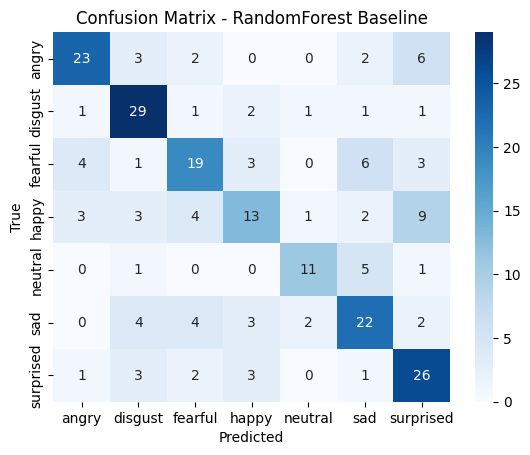

In [5]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=["label", "file_path"]).values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - RandomForest Baseline")
plt.show()

In [6]:
from sklearn.preprocessing import LabelEncoder

# Prepare features and labels
X = df.drop(columns=["label", "file_path"]).values
y = df["label"].values

# Encode labels to integers
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Reshape for CNN (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build CNN model
model = models.Sequential([
    layers.Conv1D(64, kernel_size=5, strides=1, activation="relu", input_shape=(40,1)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(128, kernel_size=5, strides=1, activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(encoder.classes_), activation="softmax")
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.2f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.2152 - loss: 2.4096 - val_accuracy: 0.2350 - val_loss: 1.9614
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3704 - loss: 1.6393 - val_accuracy: 0.2564 - val_loss: 1.8831
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4965 - loss: 1.3827 - val_accuracy: 0.2949 - val_loss: 1.6651
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5143 - loss: 1.3195 - val_accuracy: 0.4017 - val_loss: 1.5986
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5873 - loss: 1.0888 - val_accuracy: 0.4615 - val_loss: 1.5445
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6254 - loss: 1.0467 - val_accuracy: 0.4145 - val_loss: 1.5574
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6417 - loss: 0.9711 - val_accuracy: 0.4786 - val_loss: 1.4393
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6890 - loss: 0.8752 - val_accuracy: 0.5769 - v

In [7]:
model.save("emotion_model.h5")
np.save("classes.npy", encoder.classes_)

In [10]:
import librosa
import numpy as np
import tensorflow as tf

# Load model and classes
model = tf.keras.models.load_model("emotion_model.h5")
classes = np.load("classes.npy", allow_pickle=True)

def predict_emotion(file_path):
    # Extract MFCC features (same as training)
    y, sr = librosa.load(file_path, duration=3, offset=0.5)
    mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)

    # Reshape for CNN input
    mfccs = mfccs.reshape(1, mfccs.shape[0], 1)

    # Predict
    preds = model.predict(mfccs)
    pred_class = classes[np.argmax(preds)]
    confidence = np.max(preds)

    return pred_class, confidence


test_file = "/content/sample_data/03-01-04-02-02-02-03.wav"
emotion, conf = predict_emotion(test_file)
print(f"Predicted Emotion: {emotion} (Confidence: {conf:.2f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 743ms/step
Predicted Emotion: sad (Confidence: 1.00)


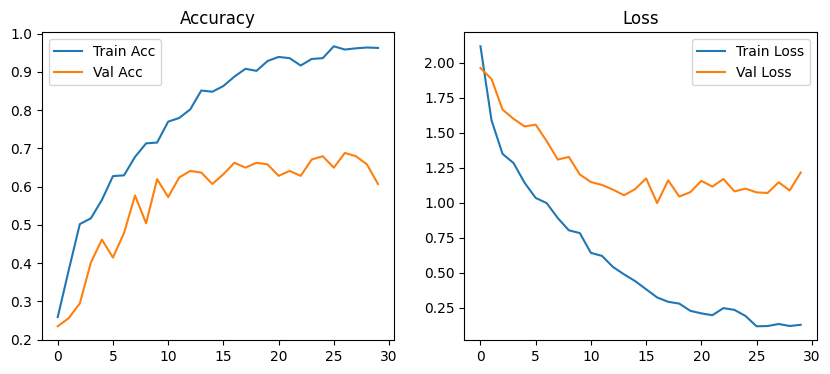

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()